In [1]:
import numpy as np
import h5py
from matplotlib import pyplot as plt

In [3]:
with h5py.File("../data/loa/preloaded-main-dark-0.h5", "r") as f:
    print(f.keys())
    # <KeysViewHDF5 ['bluesnrlist', 'flux_list', 'noise_variance_list', 'redsnrlist', 'rest_wavelength_list', 'tidlist', 'zqsolist']>
    all_zqsos = f["zqsolist"][:]
    all_tid = f["tidlist"][:]
    all_flux = f["flux_list"][:]
    all_noise_variance = f["noise_variance_list"][:]
    all_rest_wavelength = f["rest_wavelength_list"][:]
    all_redsnr = f["redsnrlist"][:]
    all_bluesnr = f["bluesnrlist"][:]
    print(all_zqsos.shape)
    print(all_tid.shape)
    print(all_flux.shape)
    print(all_noise_variance.shape)
    print(all_rest_wavelength.shape)
    print(all_redsnr.shape)

<KeysViewHDF5 ['bluesnrlist', 'flux_list', 'noise_variance_list', 'redsnrlist', 'rest_wavelength_list', 'tidlist', 'zqsolist']>
(70,)
(70,)
(70,)
(70,)
(70,)
(70,)


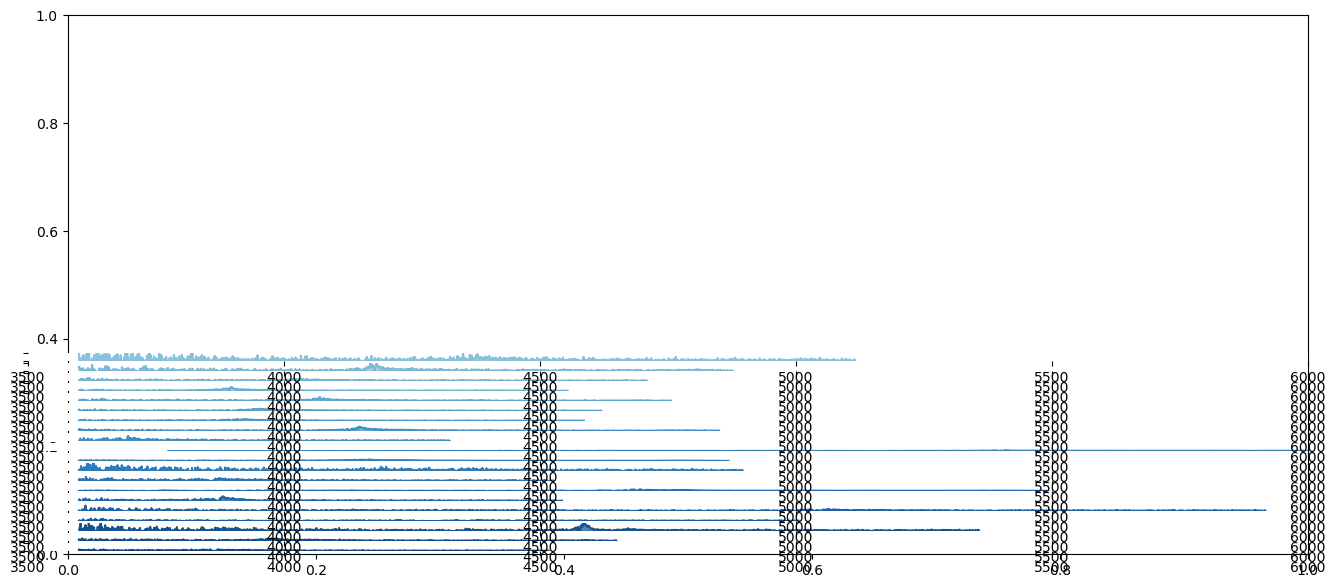

In [13]:
cmap = plt.get_cmap("RdBu_r")

################### Plotting the model ###################
fig, ax = plt.subplots(1, 1, figsize=(16, 7))
for k in range(20):
    # k = 0
    # from blue to red
    redshift_color = cmap((k + 3) / (len(all_zqsos) + 6))
    model_color = "C0"
    # I want overlap plots
    height_ratio = 1.0 * (k + 1) / len(all_zqsos)
    ax = fig.add_axes([0.1, 0.1 + height_ratio, 0.8, 0.8 / len(all_zqsos)])
    # ax = fig.add_subplot(1, 1, 1)

    # This line plots model
    ax.plot(
        all_rest_wavelength[k] * (1 + all_zqsos[k]),
        all_flux[k],
        color=redshift_color,
        label="Data",
    )  # GP model's mean function
    ax.fill_between(
        all_rest_wavelength[k] * (1 + all_zqsos[k]),
        all_flux[k],
        np.zeros_like(all_flux[k]),
        color=redshift_color,
        alpha=0.7,
        label="Absorption",
        ls="--",
    )
    # plt.text(gp.X[200] * (1 + z_qso), lya_mu[200] * normalization, "$z_{QSO} = $" + "{:.3g}".format(z_qso))

    # ax.set_xlabel("Observed-frame Wavelengths [$\AA$]", fontdict={"fontsize": 16})
    # ax.set_ylabel("Normalized Flux")
    ax.set_xlim(3500, 6000)
    ax.set_ylim(-0.5, 25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # ax.axis("off")
    ax.set(yticklabels=[])
    # fig.tight_layout()


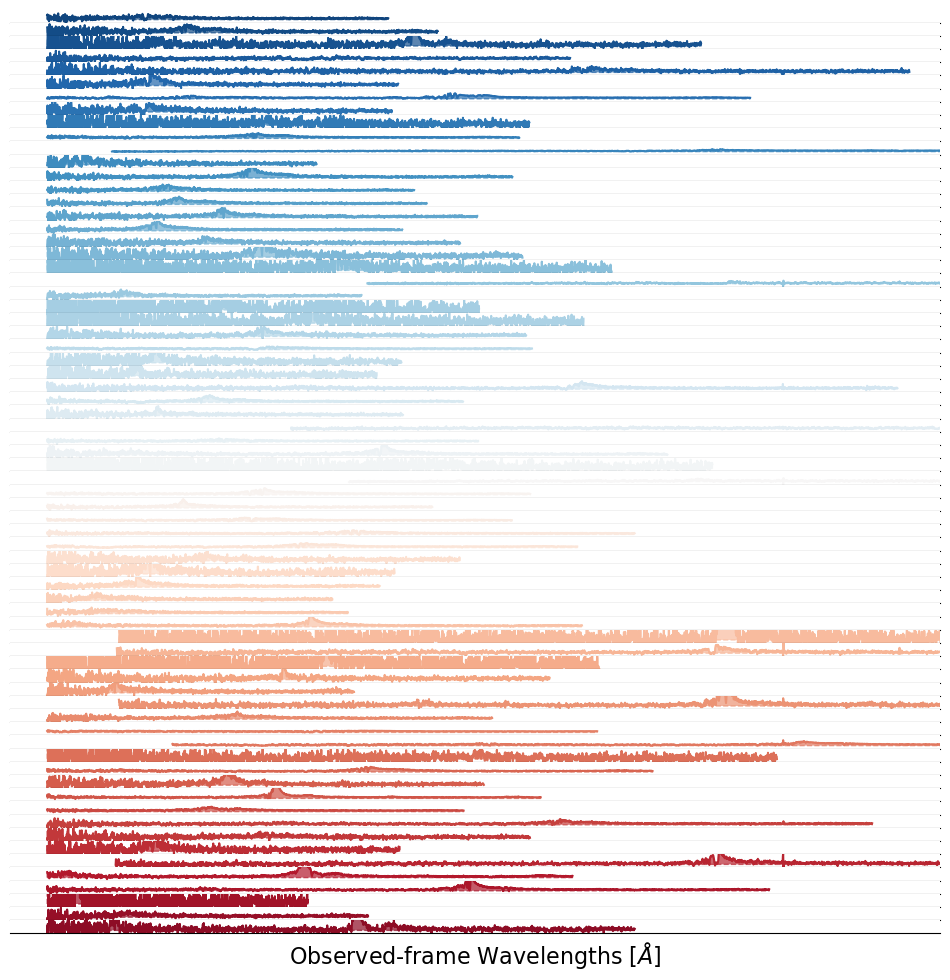

In [24]:
import numpy as np
import matplotlib.pyplot as plt

cmap = plt.get_cmap("RdBu_r")
num_spectra = 70  # Change this to the actual number of spectra
fig, axes = plt.subplots(num_spectra, 1, figsize=(12, 12), sharex=True, gridspec_kw={'hspace': 0})

for k in range(num_spectra):
    redshift_color = cmap((k + 3) / (num_spectra + 6))
    
    ax = axes[k]
    
    ax.plot(
        all_rest_wavelength[k] * (1 + all_zqsos[k]),
        all_flux[k],
        color=redshift_color,
        label="Data",
    ) 
    ax.fill_between(
        all_rest_wavelength[k] * (1 + all_zqsos[k]),
        all_flux[k],
        np.zeros_like(all_flux[k]),
        color=redshift_color,
        alpha=0.7,
        label="Absorption",
        ls="--",
    )

    ax.set_xlim(3500, 6000)
    ax.set_ylim(-3, 10)
    
    # Hide y-axis labels and ticks
    ax.set_yticklabels([])
    ax.set_yticks([])

    # Hide x-axis ticks for all except the last subplot
    if k < num_spectra - 1:
        ax.set_xticklabels([])
        ax.set_xticks([])

    # Remove spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    
# Set x-axis label at the bottom
axes[-1].set_xlabel("Observed-frame Wavelengths [$\AA$]", fontsize=16)

plt.show()

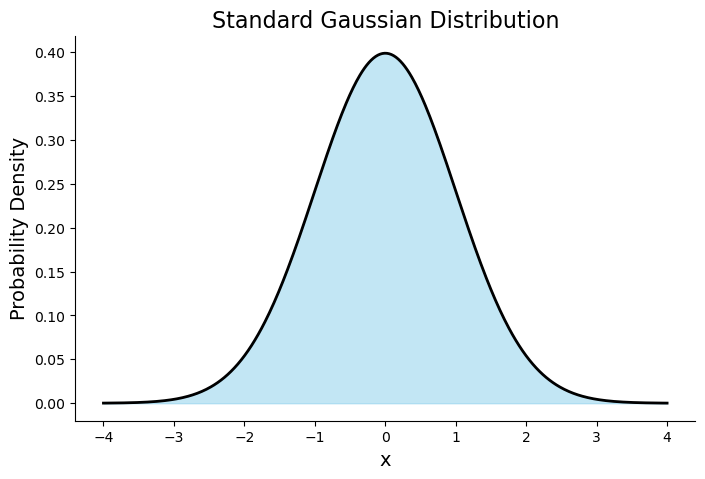

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_standard_gaussian_transparent(shade_color="skyblue", alpha=0.5, xlim=(-4, 4), figsize=(8, 5)):
    """
    Plots a standard Gaussian distribution with the area under the curve shaded and a transparent background.
    
    Parameters:
    - shade_color: Color for the shaded area under the curve.
    - alpha: Transparency level of the shaded area.
    - xlim: Tuple (xmin, xmax) defining the x-axis limits.
    - figsize: Figure size.
    """
    x = np.linspace(xlim[0], xlim[1], 500)
    y = norm.pdf(x, 0, 1)  # Standard normal distribution

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_alpha(0)  # Transparent background for the figure
    ax.patch.set_alpha(0)   # Transparent background for the axes

    ax.plot(x, y, color="black", lw=2, label="Standard Normal Distribution")
    ax.fill_between(x, y, color=shade_color, alpha=alpha)

    ax.set_xlabel("x", fontsize=14)
    ax.set_ylabel("Probability Density", fontsize=14)
    ax.set_title("Standard Gaussian Distribution", fontsize=16)

    # Remove spines for a cleaner look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.show()

# Example usage:
plot_standard_gaussian_transparent()

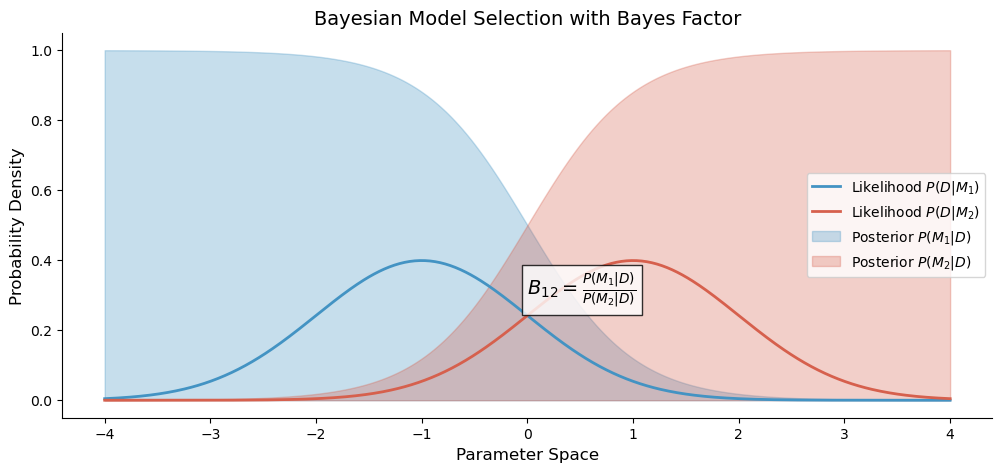

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_bayes_factor(save_path=None):
    """
    Generates a plot to demonstrate Bayes factor and Bayesian model selection.

    Parameters:
    - save_path: If provided, saves the figure to the specified path.
    """
    x = np.linspace(-4, 4, 500)
    cmap = plt.get_cmap("RdBu_r")

    # Define two models with different likelihoods
    mu1, sigma1 = -1, 1  # Model 1: Gaussian centered at -1
    mu2, sigma2 = 1, 1   # Model 2: Gaussian centered at 1

    likelihood1 = norm.pdf(x, mu1, sigma1)
    likelihood2 = norm.pdf(x, mu2, sigma2)

    # Assume equal priors for simplicity
    prior1, prior2 = 0.5, 0.5

    # Compute posterior ratio (Bayes Factor proportionality)
    evidence = likelihood1 * prior1 + likelihood2 * prior2
    posterior1 = (likelihood1 * prior1) / evidence
    posterior2 = (likelihood2 * prior2) / evidence
    bayes_factor = posterior1 / posterior2  # Ratio of posteriors

    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Plot likelihoods
    ax.plot(x, likelihood1, color=cmap(0.2), lw=2, label="Likelihood $P(D | M_1)$")
    ax.plot(x, likelihood2, color=cmap(0.8), lw=2, label="Likelihood $P(D | M_2)$")

    # Shaded posterior regions
    ax.fill_between(x, posterior1, color=cmap(0.2), alpha=0.3, label="Posterior $P(M_1 | D)$")
    ax.fill_between(x, posterior2, color=cmap(0.8), alpha=0.3, label="Posterior $P(M_2 | D)$")

    # Annotate Bayes factor
    ax.text(0, 0.3, r"$B_{12} = \frac{P(M_1 | D)}{P(M_2 | D)}$", fontsize=14, bbox=dict(facecolor='white', alpha=0.8))

    ax.set_xlabel("Parameter Space", fontsize=12)
    ax.set_ylabel("Probability Density", fontsize=12)
    ax.set_title("Bayesian Model Selection with Bayes Factor", fontsize=14)

    ax.legend()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    
    plt.show()

# Run the function to generate the plot
plot_bayes_factor()

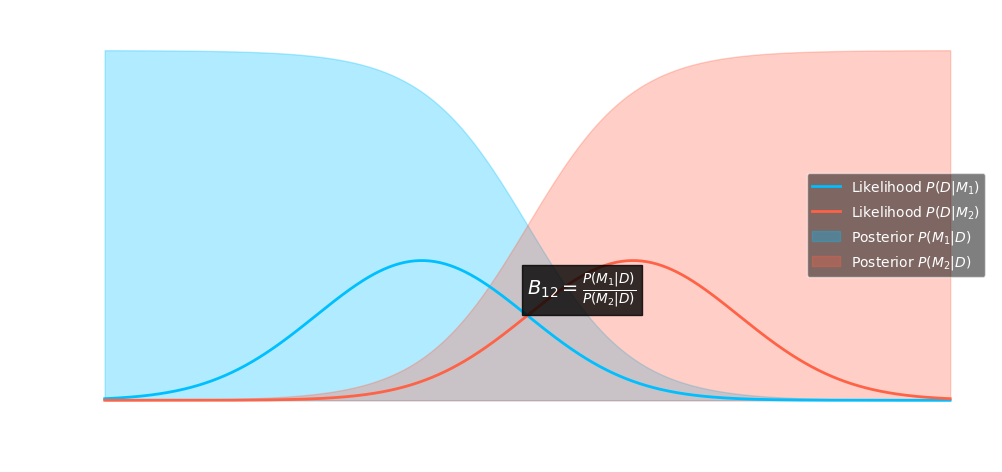

In [31]:
# Re-import necessary libraries after execution state reset
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_bayes_factor_transparent(save_path=None):
    """
    Generates a Bayes factor plot with a transparent background and white labels/text.
    Designed for use on black slides.

    Parameters:
    - save_path: If provided, saves the figure to the specified path.
    """
    x = np.linspace(-4, 4, 500)

    # Define two models with different likelihoods
    mu1, sigma1 = -1, 1  # Model 1: Gaussian centered at -1
    mu2, sigma2 = 1, 1   # Model 2: Gaussian centered at 1

    likelihood1 = norm.pdf(x, mu1, sigma1)
    likelihood2 = norm.pdf(x, mu2, sigma2)

    # Assume equal priors for simplicity
    prior1, prior2 = 0.5, 0.5

    # Compute posterior ratio (Bayes Factor proportionality)
    evidence = likelihood1 * prior1 + likelihood2 * prior2
    posterior1 = (likelihood1 * prior1) / evidence
    posterior2 = (likelihood2 * prior2) / evidence
    bayes_factor = posterior1 / posterior2  # Ratio of posteriors

    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Set transparent background
    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)

    # Plot likelihoods
    ax.plot(x, likelihood1, color="deepskyblue", lw=2, label="Likelihood $P(D | M_1)$")
    ax.plot(x, likelihood2, color="tomato", lw=2, label="Likelihood $P(D | M_2)$")

    # Shaded posterior regions
    ax.fill_between(x, posterior1, color="deepskyblue", alpha=0.3, label="Posterior $P(M_1 | D)$")
    ax.fill_between(x, posterior2, color="tomato", alpha=0.3, label="Posterior $P(M_2 | D)$")

    # Annotate Bayes factor
    ax.text(0, 0.3, r"$B_{12} = \frac{P(M_1 | D)}{P(M_2 | D)}$", 
            fontsize=14, color="white", bbox=dict(facecolor='black', alpha=0.8))

    # Set white labels and title for black slides
    ax.set_xlabel("Parameter Space", fontsize=12, color="white")
    ax.set_ylabel("Probability Density", fontsize=12, color="white")
    ax.set_title("Bayesian Model Selection with Bayes Factor", fontsize=14, color="white")

    # Set ticks to white
    ax.tick_params(axis='both', colors="white")

    # Set spines to white
    for spine in ax.spines.values():
        spine.set_color("white")

    ax.legend(facecolor='black', framealpha=0.5, edgecolor='white', labelcolor='white')

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
    
    plt.show()

# Run the function to generate the plot
plot_bayes_factor_transparent()

## Mock low SNR plot

In [3]:
with h5py.File("../data/london/preloaded-spectra-16-1654.h5", "r") as f:
    print(f.keys())
    # <KeysViewHDF5 ['bluesnrlist', 'flux_list', 'noise_variance_list', 'redsnrlist', 'rest_wavelength_list', 'tidlist', 'zqsolist']>
    all_zqsos = f["zqsolist"][:]
    all_tid = f["tidlist"][:]
    all_flux = f["flux_list"][:]
    all_noise_variance = f["noise_variance_list"][:]
    all_rest_wavelength = f["rest_wavelength_list"][:]
    all_redsnr = f["redsnrlist"][:]
    all_bluesnr = f["bluesnrlist"][:]
    print(all_zqsos.shape)
    print(all_tid.shape)
    print(all_flux.shape)
    print(all_noise_variance.shape)
    print(all_rest_wavelength.shape)
    print(all_redsnr.shape)

<KeysViewHDF5 ['bluesnrlist', 'flux_list', 'noise_variance_list', 'redsnrlist', 'rest_wavelength_list', 'tidlist', 'zqsolist']>
(1110,)
(1110,)
(1110,)
(1110,)
(1110,)
(1110,)


In [4]:
from astropy.table import Table

truecat = Table.read("../data/london/dla_cat_mask_20.30.fits")

In [59]:
ind = np.isin(all_tid, truecat["TARGETID"])
ind &= all_zqsos > 3
ind &= (all_redsnr < 3)
real_index = np.where(ind)[0]



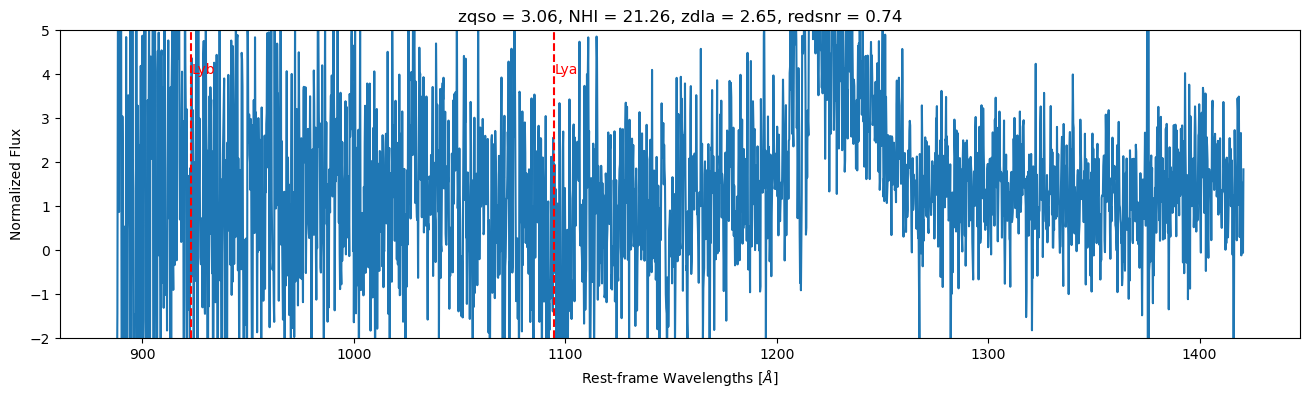

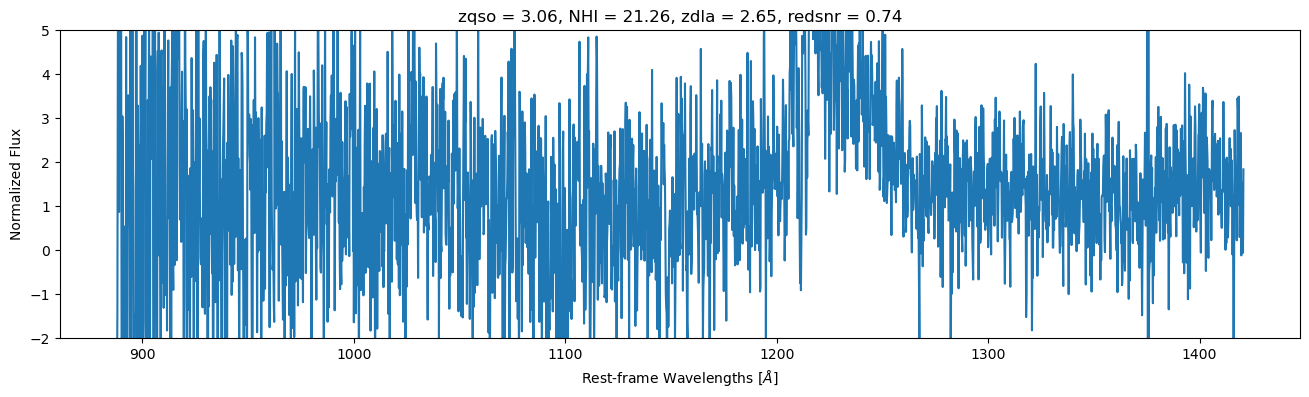

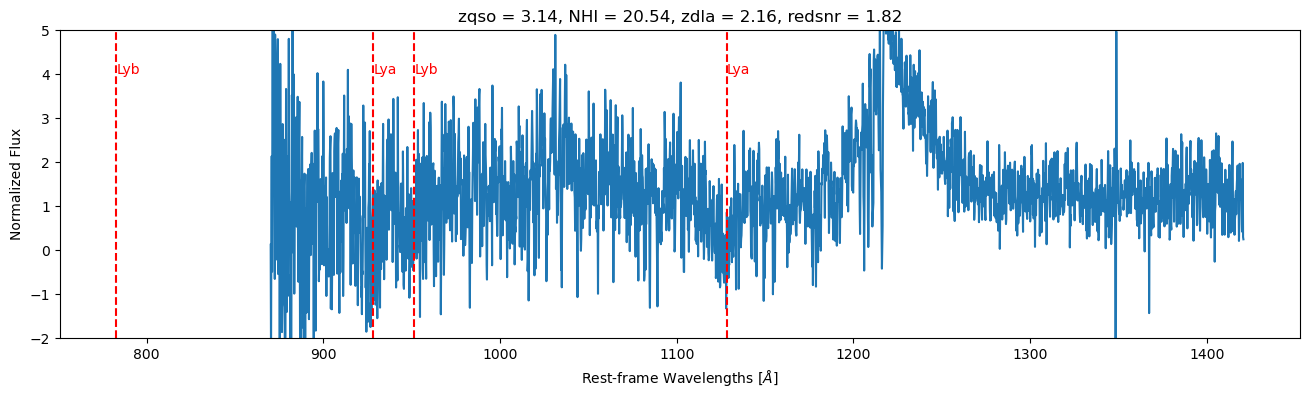

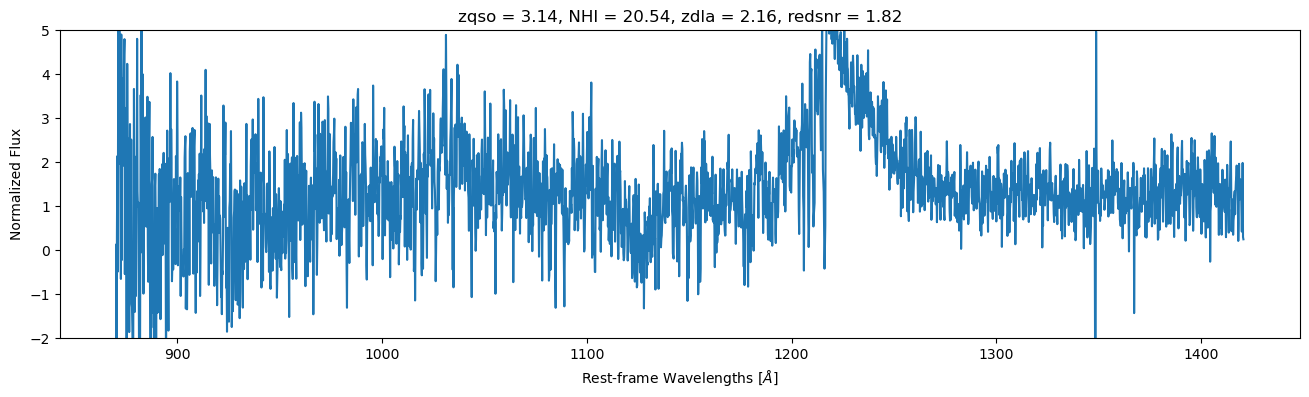

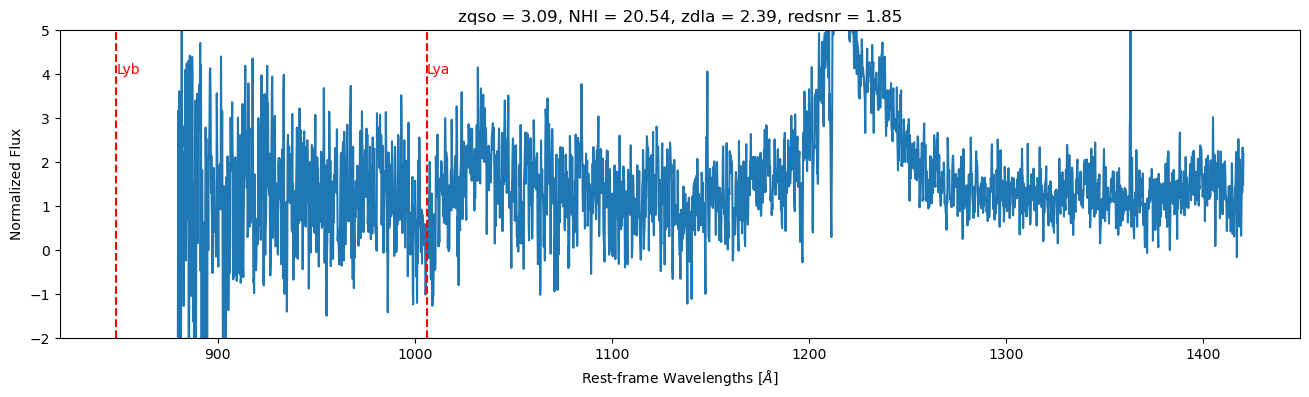

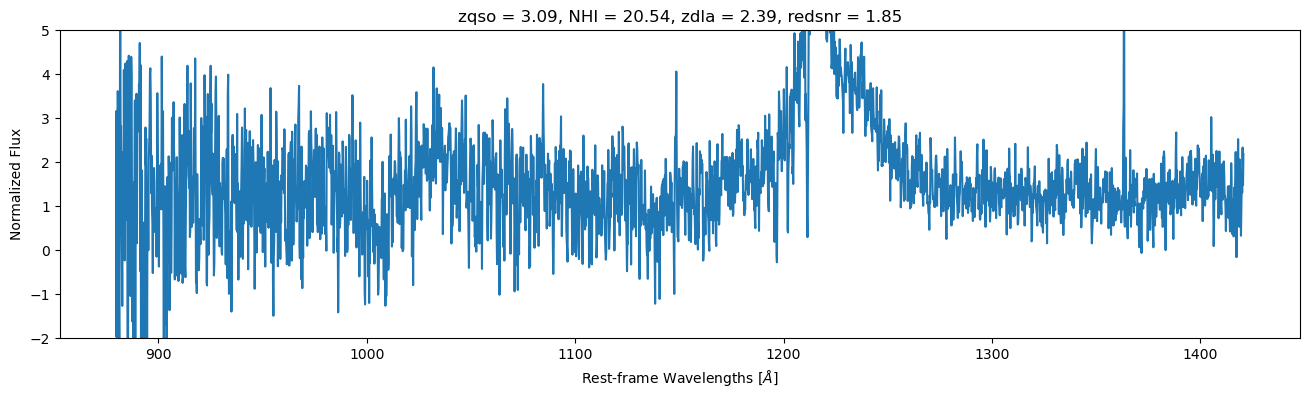

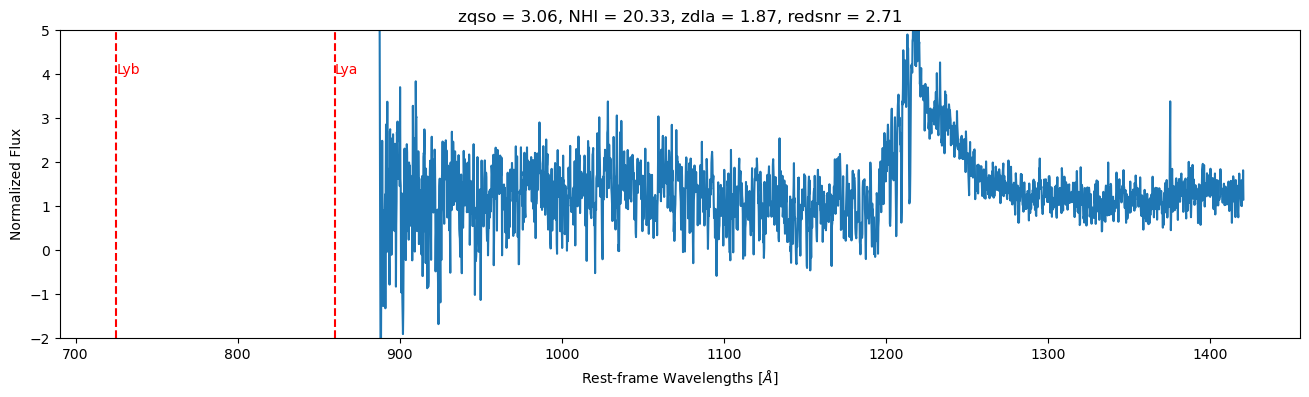

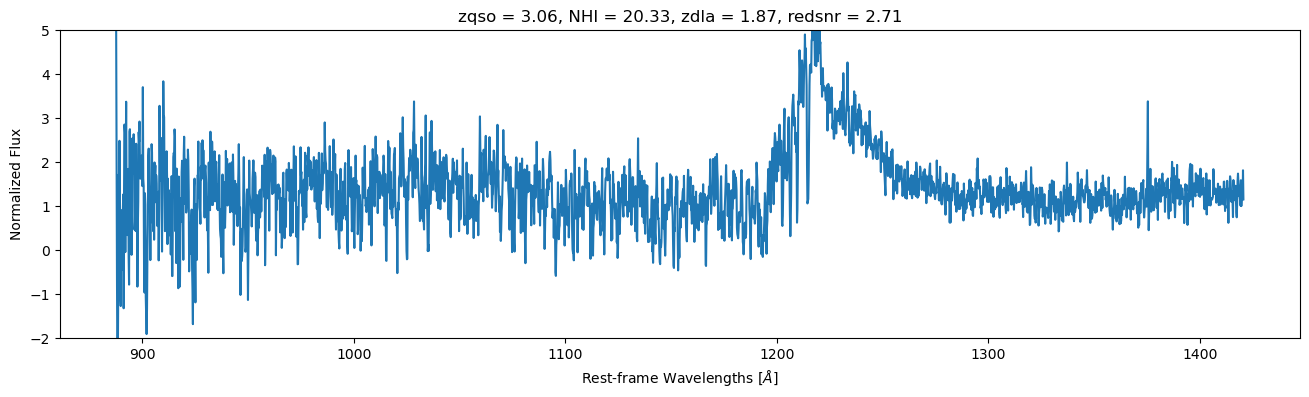

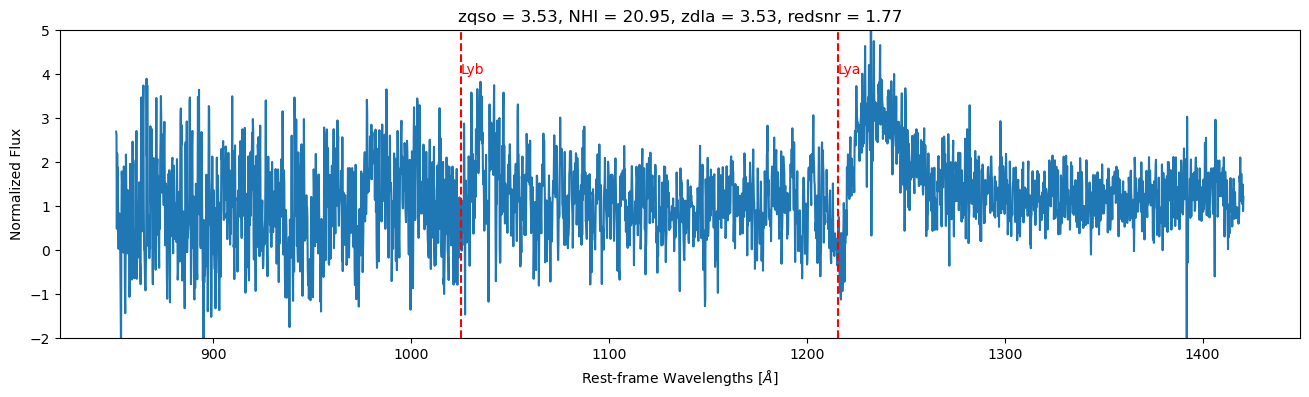

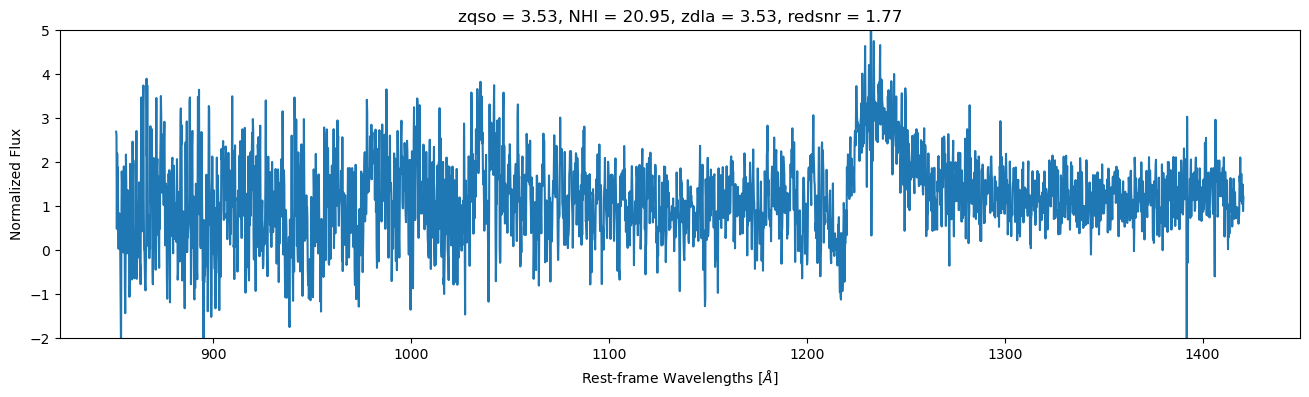

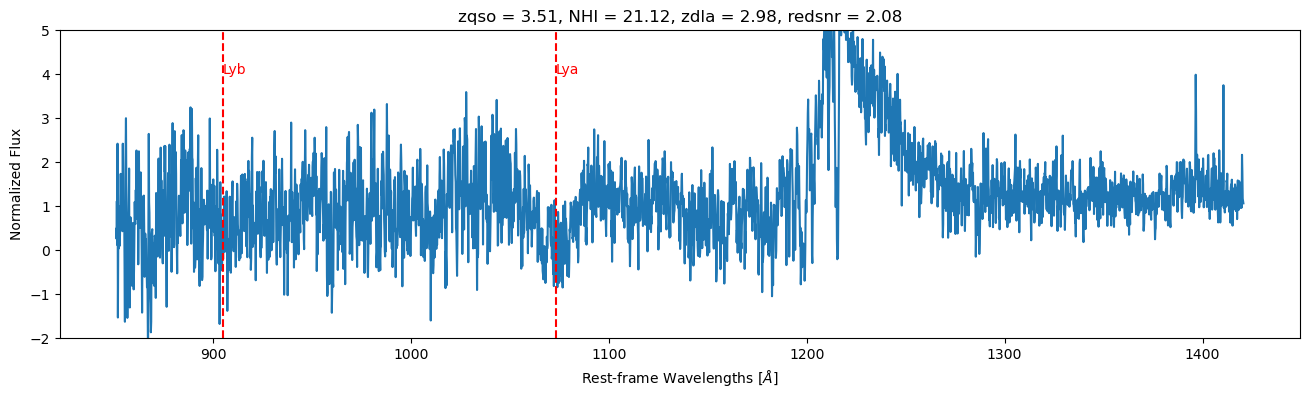

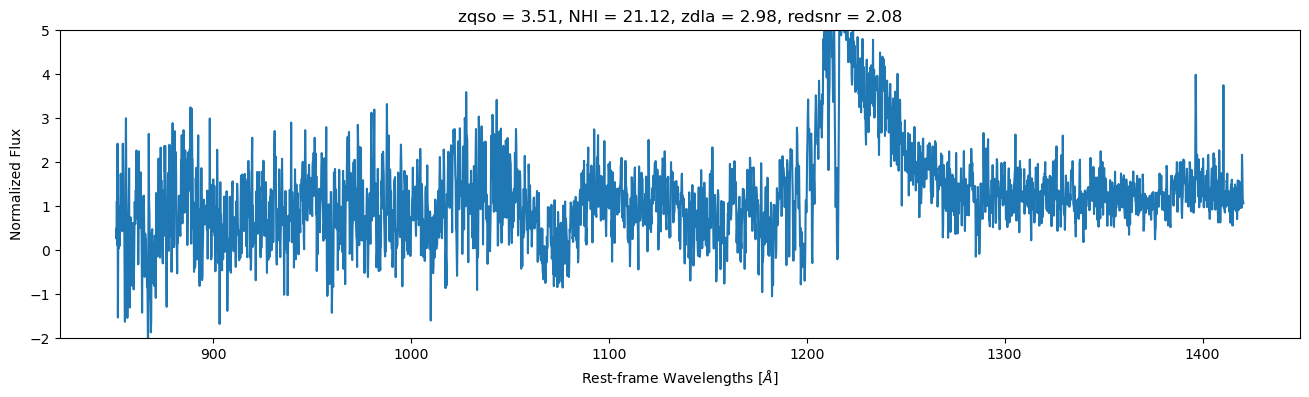

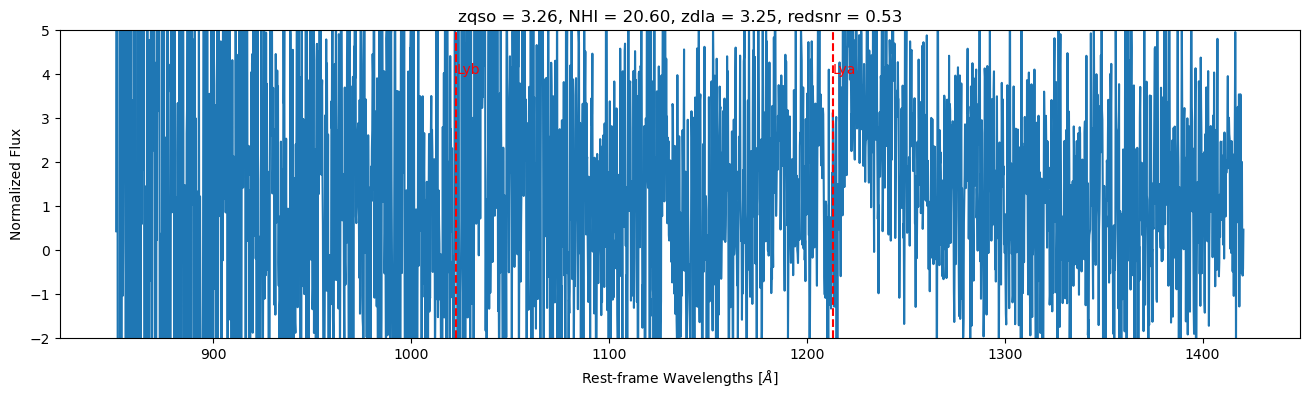

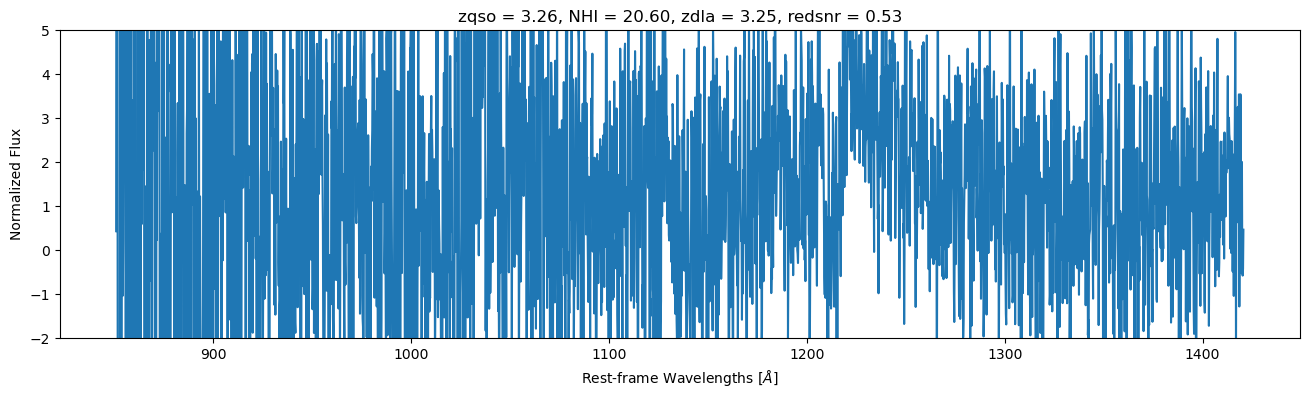

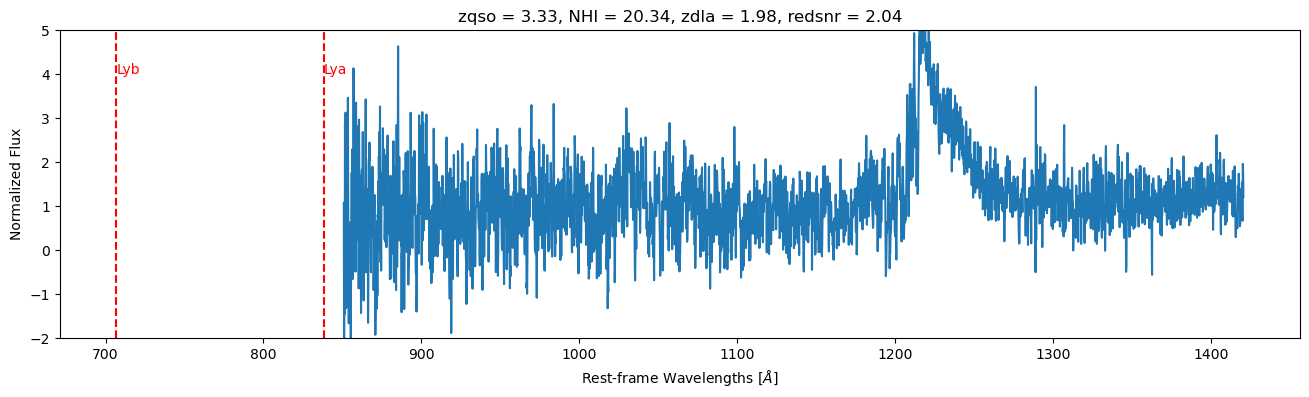

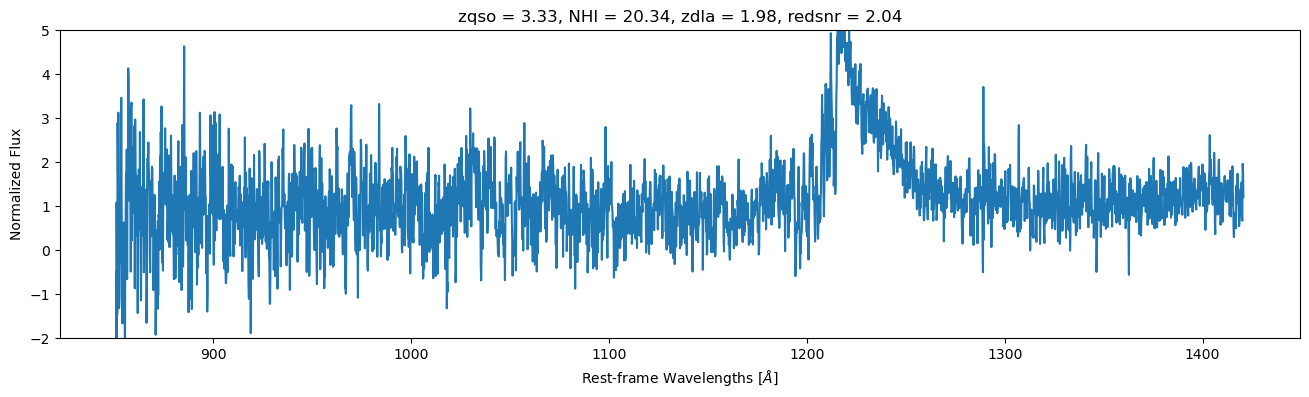

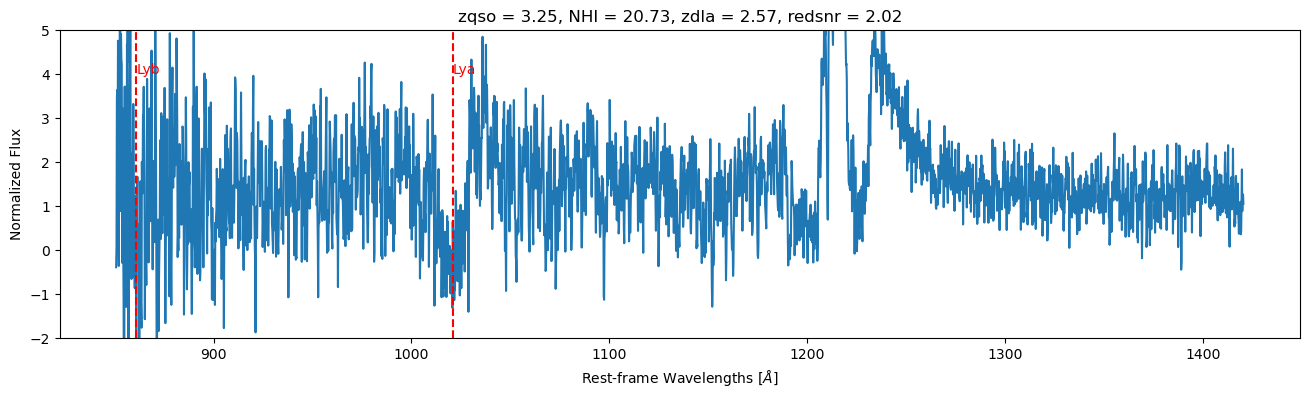

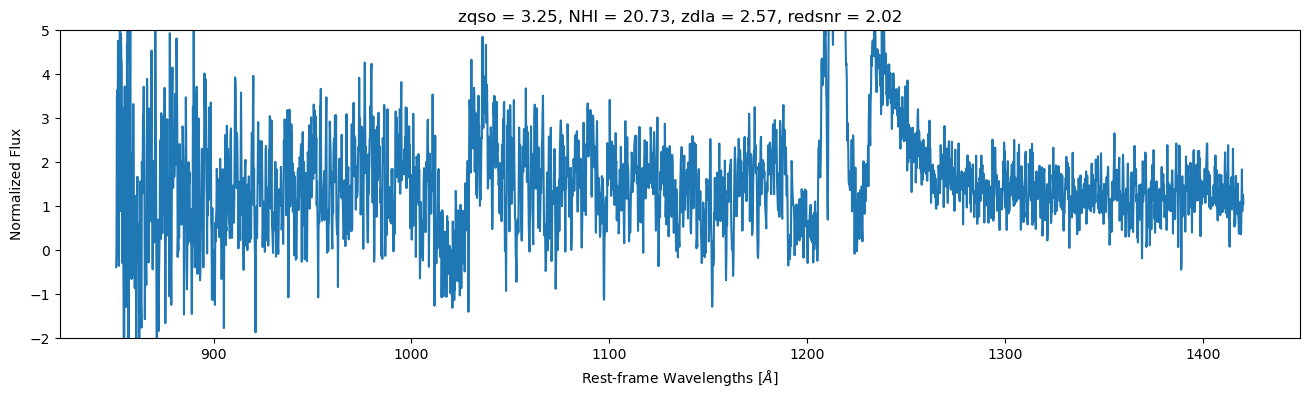

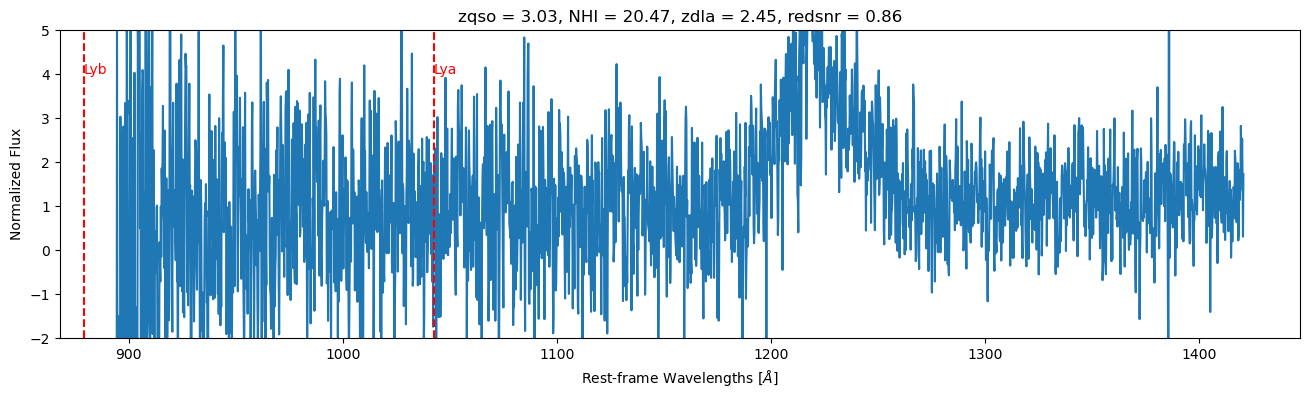

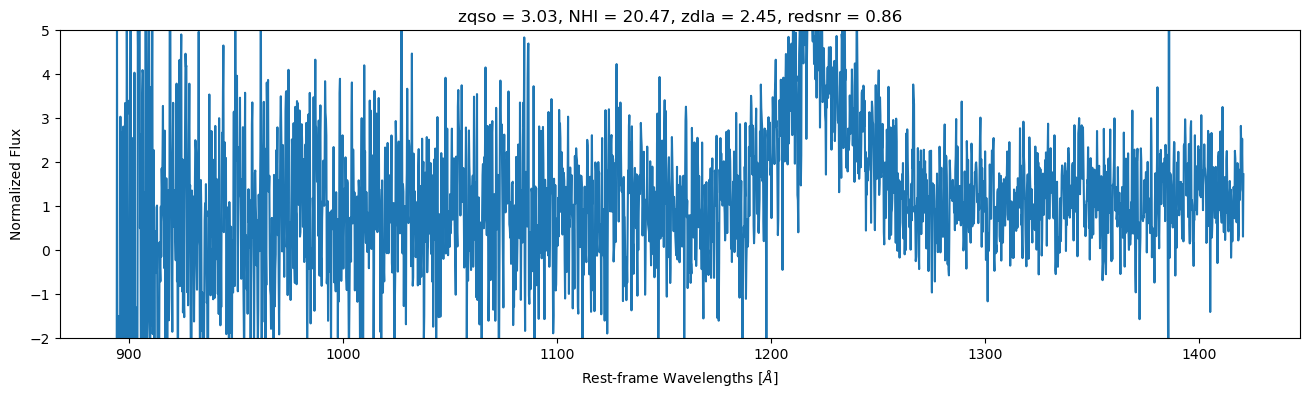

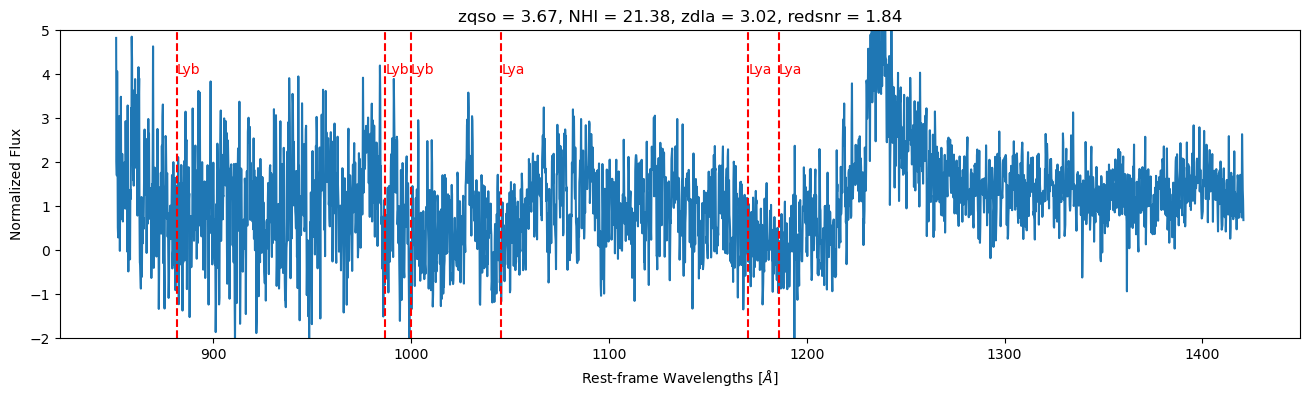

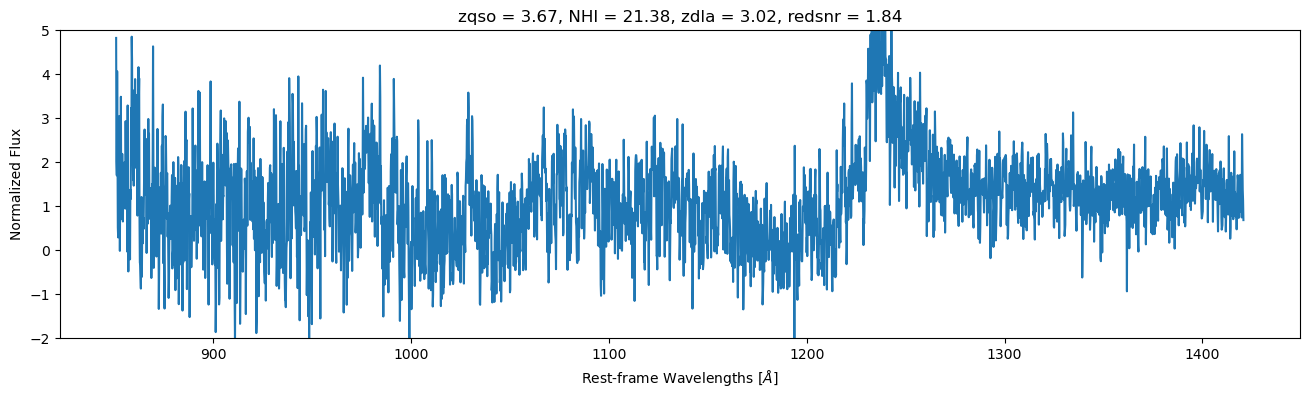

In [65]:


# from the truecat, the nhi and zdla

index = real_index[0]

for i, index in enumerate(real_index):
    tid = all_tid[index]
    nhi = truecat["NHI"][np.isin(truecat["TARGETID"], tid)]
    zdla = truecat["Z_DLA"][np.isin(truecat["TARGETID"], tid)]

    plt.figure(figsize=(16, 4))
    plt.plot(all_rest_wavelength[index], all_flux[index])

    for i in range(len(nhi)):
        # label the DLA
        plt.axvline(1215.67 * (1 + zdla[i]) / (1 + all_zqsos[index]), color="red", ls="--")
        plt.axvline(1025 * (1 + zdla[i]) / (1 + all_zqsos[index]), color="red", ls="--")
        # text of Lya and Lyb
        plt.text(1215.67 * (1 + zdla[i]) / (1 + all_zqsos[index]), 4, "Lya", color="red")
        plt.text(1025 * (1 + zdla[i]) / (1 + all_zqsos[index]), 4, "Lyb", color="red")
    # only to floating point .2
    plt.title(f"zqso = {all_zqsos[index]:.2f}, NHI = {nhi[0]:.2f}, zdla = {zdla[0]:.2f}, redsnr = {all_redsnr[index]:.2f}")
    # plt.xlim(3500, 6000)
    plt.ylim(-2, 5)
    plt.xlabel("Rest-frame Wavelengths [$\AA$]")
    plt.ylabel("Normalized Flux")
    plt.show()

    plt.figure(figsize=(16, 4))
    plt.plot(all_rest_wavelength[index], all_flux[index])

    plt.title(f"zqso = {all_zqsos[index]:.2f}, NHI = {nhi[0]:.2f}, zdla = {zdla[0]:.2f}, redsnr = {all_redsnr[index]:.2f}")
    # plt.xlim(3500, 6000)
    plt.ylim(-2, 5)
    plt.xlabel("Rest-frame Wavelengths [$\AA$]")
    plt.ylabel("Normalized Flux")
    plt.show()